# 01 — Data audit before modeling

This notebook establishes what the first model is allowed to learn from. The target is the
**publication's weak AllSides label**, not a human judgment of each headline. We use only
`headline` as model text; RSS summaries are reserved for a later ablation because they are
not consistently true subheadlines.

Run notebooks in numeric order. Each code cell performs one visible audit step.

## Reproducibility setup

`ROOT` makes the notebook work whether Jupyter starts in the repository or `notebooks/`.
No random operation occurs in this audit.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA_PATH = ROOT / "data/processed/publication_proxy_headlines.csv"

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bias_dataset.modeling import LABEL_ORDER, load_modeling_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

## Load the frozen processed snapshot

In [3]:
data = load_modeling_data(DATA_PATH)
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
data[["record_id", "source_id", "headline", "weak_label"]].head()

Rows: 1,033
Columns: 28


,record_id,source_id,headline,weak_label
0,4635aacf62952a624ca2a8564201e8355ea0cb01f1d83db83e7a763ecffa8c69,cnn,The 2024 presidential alternative many voters will want,Lean Left
1,54d03d8e006392742494cc2f473ce2bd2340b749fcb442bdd20cce463f242616,cnn,"Russia is 'going backwards' in equipment and deploying post WWII-era tanks, according to Western...",Lean Left
2,5561eb4d0084c49afa57b87c37a157493e930e3866f082c452e759c00b9ac90e,cnn,Dominion still has pending lawsuits against election deniers such as Rudy Giuliani and Sidney Po...,Lean Left
3,e6f7461b12cc8b342fc85e0578b28f315e68a5f74ad80d61909fed4f0c55bc3a,cnn,CNN Political Briefing,Lean Left
4,f1ef285a4c60a5b59bd5e1eacbc74828e5ea92a79e742d9a9ed5170e810477bc,cnn,The Axe Files with David Axelrod,Lean Left


## Validate identity and label semantics

Duplicate record IDs would make the same observation count more than once. `label_scope`
must remain `outlet`, which prevents us from accidentally describing these weak labels as
headline-level ground truth.

In [4]:
identity_checks = pd.Series({
    "unique_record_ids": data["record_id"].nunique(),
    "duplicate_record_ids": data["record_id"].duplicated().sum(),
    "blank_headlines": data["model_text"].eq("").sum(),
    "outlet_scope_rows": data["label_scope"].eq("outlet").sum(),
})
identity_checks

unique_record_ids       1033
duplicate_record_ids       0
blank_headlines            0
outlet_scope_rows       1033
dtype: int64

## Class distribution

In [5]:
class_counts = data["weak_label"].value_counts().reindex(LABEL_ORDER)
class_counts.to_frame("records")

,records
weak_label,
Left,226
Lean Left,164
Center,153
Lean Right,347
Right,143


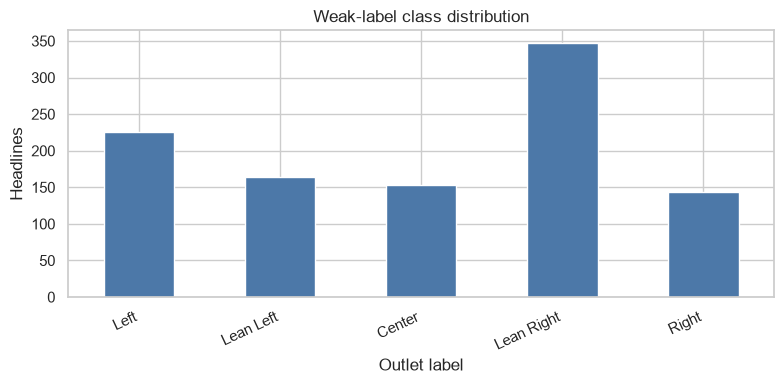

In [6]:
ax = class_counts.plot.bar(color="#4C78A8", figsize=(8, 4))
ax.set(title="Weak-label class distribution", xlabel="Outlet label", ylabel="Headlines")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The class imbalance is visible before modeling. We retain the natural archive and use
`class_weight='balanced'` in Logistic Regression rather than synthesizing TF-IDF vectors.

## Publication concentration inside each class

In [7]:
outlet_counts = (
    data.groupby(["weak_label", "source_id"], observed=True)
    .size().rename("records").reset_index()
)
outlet_counts["weak_label"] = pd.Categorical(
    outlet_counts["weak_label"], categories=LABEL_ORDER, ordered=True
)
outlet_counts.sort_values(["weak_label", "records"], ascending=[True, False])

,weak_label,source_id,records
10,Left,mother_jones,153
11,Left,the_atlantic,59
12,Left,vox,14
5,Lean Left,mediaite,56
4,Lean Left,cnn,44
3,Lean Left,abc_news,37
6,Lean Left,nbc_news,27
2,Center,the_hill,73
1,Center,newsnation,57
0,Center,cs_monitor,23


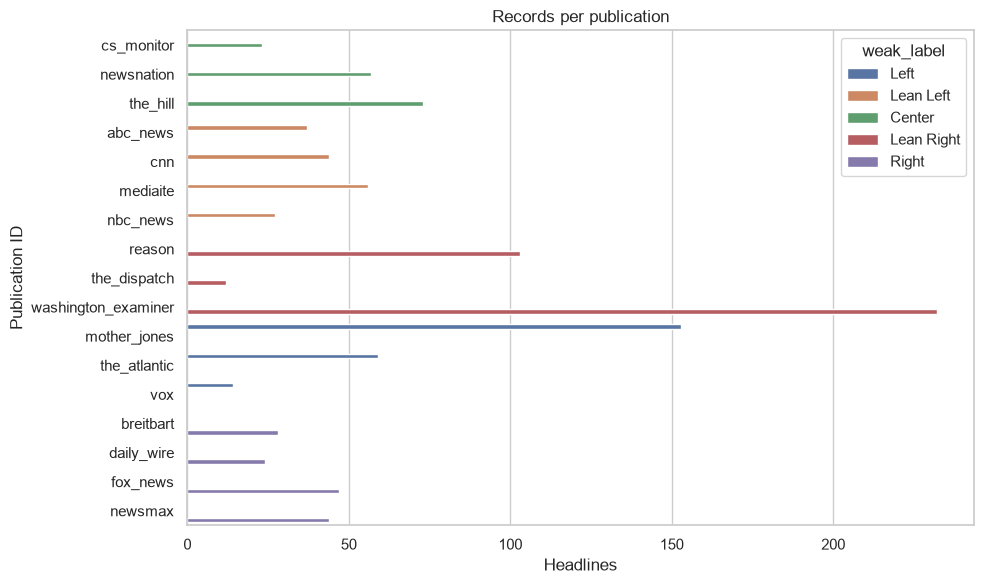

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=outlet_counts, y="source_id", x="records", hue="weak_label", hue_order=LABEL_ORDER)
plt.title("Records per publication")
plt.xlabel("Headlines")
plt.ylabel("Publication ID")
plt.tight_layout()
plt.show()

## Headline length and vocabulary surface

In [9]:
data["headline_words"] = data["model_text"].str.split().str.len()
data["headline_chars"] = data["model_text"].str.len()
data[["headline_words", "headline_chars"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(1)

,headline_words,headline_chars
count,1033.0,1033.0
mean,11.0,69.9
std,3.5,22.0
min,3.0,14.0
5%,6.0,31.6
25%,9.0,55.0
50%,11.0,70.0
75%,13.0,83.0
95%,17.0,106.0
max,23.0,145.0


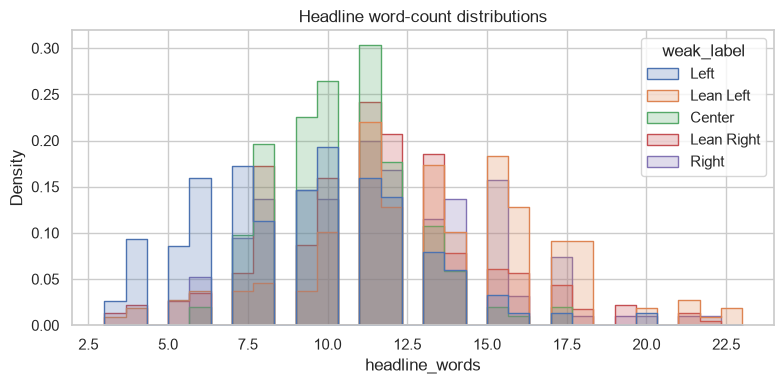

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="headline_words", hue="weak_label", hue_order=LABEL_ORDER,
             element="step", stat="density", common_norm=False, bins=30)
plt.title("Headline word-count distributions")
plt.tight_layout()
plt.show()

## Time coverage

In [11]:
time_summary = data.groupby("source_id").agg(
    first_record=("model_timestamp", "min"),
    last_record=("model_timestamp", "max"),
    records=("record_id", "size"),
)
time_summary.sort_values("first_record")

,first_record,last_record,records
source_id,,,
cnn,2022-11-29 23:32:13+00:00,2026-08-27 09:14:59.558062+00:00,44
the_atlantic,2026-07-07 15:30:00+00:00,2026-08-26 22:18:48+00:00,59
nbc_news,2026-07-20 21:52:47+00:00,2026-08-27 01:19:18+00:00,27
mother_jones,2026-07-22 10:00:00+00:00,2026-08-26 20:57:42+00:00,153
cs_monitor,2026-07-30 19:09:50+00:00,2026-08-27 09:00:10+00:00,23
vox,2026-07-31 21:54:47+00:00,2026-08-25 22:55:09+00:00,14
the_dispatch,2026-08-07 05:02:00+00:00,2026-08-27 07:00:00+00:00,12
reason,2026-08-11 11:00:36+00:00,2026-08-26 22:02:56+00:00,103
fox_news,2026-08-19 11:15:00+00:00,2026-08-27 09:00:52+00:00,47


Archive depth differs greatly between sources. Notebook 02 therefore makes the validation
tail **within each development outlet**, avoiding a global date cutoff that could remove
entire publications merely because their feed exposed older material.

## Holdout design and unavailable true subheadlines

In [12]:
holdout_summary = (
    data.groupby(["weak_label", "source_id", "holdout_outlet"], observed=True)
    .size().rename("records").reset_index()
)
holdout_summary[holdout_summary["holdout_outlet"]].sort_values("weak_label")

,weak_label,source_id,holdout_outlet,records
0,Center,cs_monitor,True,23
4,Lean Left,cnn,True,44
9,Lean Right,washington_examiner,True,232
10,Left,mother_jones,True,153
16,Right,newsmax,True,44


In [13]:
text_availability = pd.Series({
    "true_subheadlines": data["subheadline"].fillna("").ne("").sum(),
    "rss_summaries": data["feed_summary"].fillna("").ne("").sum(),
    "missing_publisher_timestamps": pd.to_datetime(data["published_at"], errors="coerce", utc=True).isna().sum(),
})
text_availability

true_subheadlines                  0
rss_summaries                   1018
missing_publisher_timestamps       5
dtype: int64

## Audit conclusion

The snapshot is large enough for a **pilot**, not a final performance claim. The first
experiment will use headline-only word TF-IDF, balanced Logistic Regression, a temporal
validation tail, and five untouched publication holdouts. The most important limitation is
construct validity: success means predicting outlet-associated language/content patterns.